In [1]:
import os

import numpy as np
import pandas as pd

from matplotlib import pyplot as plt

from sklearn import preprocessing
from sklearn import metrics
from sklearn import pipeline
from sklearn import model_selection

import pickle

In [2]:
dataset_dir = "dataset"
models_dir = "models"

In [3]:
data_df = pd.read_csv(os.path.join(dataset_dir, "train_set.csv"))
X_train = data_df.drop(columns=["TARGET"])
y_train = data_df["TARGET"]

We have an imbalanced dataset.

In [4]:
n_neg, n_pos = np.bincount(y_train.astype(int))

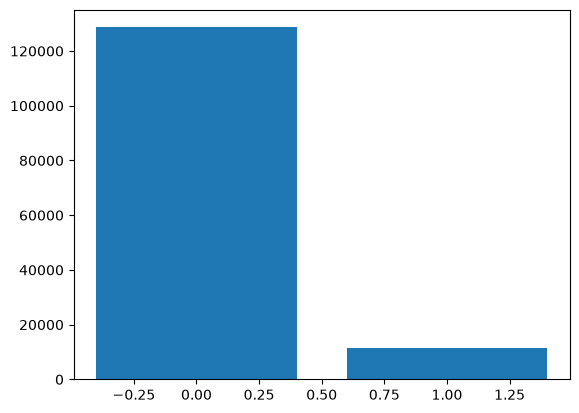

In [5]:
plt.bar([0, 1], [n_neg, n_pos])
plt.show()

## Logistic regression

In [6]:
from sklearn.linear_model import LogisticRegression

In [7]:
params = {
    "lr__C": [10 ** i for i in range(-4, 1)]
}

In [8]:
lr_pipe = pipeline.Pipeline(steps=[
    ("scaler", preprocessing.StandardScaler()),
    ("lr", LogisticRegression(class_weight="balanced"))
])
grid = model_selection.GridSearchCV(estimator=lr_pipe, param_grid=params, scoring="f1_macro", cv=5)
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...'balanced'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'lr__C': [0.0001, 0.001, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fittin

In [9]:
grid.best_params_

{'lr__C': 0.01}

Saving the model.

In [10]:
model_path = os.path.join(models_dir, "lr_pipe.pkl")
with open(model_path, "wb") as file:
    pickle.dump(grid.best_estimator_, file)

## XGBoost

In [11]:
import xgboost

In [12]:
params = {
    "n_estimators": [100, 200, 500],
    "max_depth": [3, 5, 10]
}

In [13]:
xgb_clf = xgboost.XGBClassifier(scale_pos_weight=n_neg / n_pos)
grid = model_selection.GridSearchCV(estimator=xgb_clf, param_grid=params, scoring="f1_macro", cv=5)
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of inf

In [14]:
grid.best_params_

{'max_depth': 10, 'n_estimators': 100}

Saving the model.

In [15]:
model_path = os.path.join(models_dir, "xgb_clf.pkl")
with open(model_path, "wb") as file:
    pickle.dump(grid.best_estimator_, file)

## Fully-connected neural network

In [16]:
import torch
import torch.nn as nn
from torch.nn import functional as F

In [17]:
BATCH_SIZE = 1024
NUM_EPOCHS = 25
LEARNING_RATE = 1e-4
DROPOUT = 0.3
WEIGHT_DECAY = 1e-2

In [18]:
X_train_t, X_val_t, y_train_t, y_val_t = model_selection.train_test_split(
    X_train,
    y_train,
    train_size=0.8,
    stratify=y_train,
    random_state=42
)

In [19]:
scaler = preprocessing.StandardScaler()
scaler.fit(X_train_t)
X_train_t = scaler.transform(X_train_t)
X_val_t = scaler.transform(X_val_t)

In [20]:
X_train_t = torch.tensor(X_train_t, dtype=torch.float32)
X_val_t = torch.tensor(X_val_t, dtype=torch.float32)
y_train_t = torch.tensor(y_train_t.values, dtype=torch.float32).reshape(-1, 1)
y_val_t = torch.tensor(y_val_t.values, dtype=torch.float32).reshape(-1, 1)


train_dataset = torch.utils.data.TensorDataset(X_train_t, y_train_t)
val_dataset = torch.utils.data.TensorDataset(X_val_t, y_val_t)

train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = torch.utils.data.DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [21]:
class NNBinaryClassifier(nn.Module):
    def __init__(self, in_features, dropout=0.0):
        super().__init__()
        self.seq = nn.Sequential(
            nn.Linear(in_features=in_features, out_features=128),
            nn.ReLU(),
            nn.Dropout(p=dropout),
            nn.Linear(in_features=128, out_features=64),
            nn.ReLU(),
            nn.Dropout(p=dropout),
            nn.Linear(in_features=64, out_features=1)
        )

    def forward(self, x):
        return self.seq(x)

In [22]:
num_features = X_train_t.shape[1]

We have imbalanced data, so we compute weights that are used later for BCE loss.

In [23]:
pos_weight = torch.tensor([n_neg / n_pos])

In [28]:
fcnn = NNBinaryClassifier(in_features=num_features, dropout=DROPOUT)

optimizer = torch.optim.AdamW(fcnn.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

stats = {
    "train_step": [],
    "train_loss": [],
    "train_acc": [],
    "val_step": [],
    "val_loss": [],
    "val_acc": []
}

step = 0
for epoch in range(NUM_EPOCHS):
    fcnn.train()
    for X_batch, y_batch in train_dataloader:
        y_logits = fcnn(X_batch)

        loss = F.binary_cross_entropy_with_logits(y_logits, y_batch, pos_weight=pos_weight)
        y_pred = (torch.sigmoid(y_logits) > 0.5).to(dtype=torch.float32)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        stats["train_step"].append(step)
        stats["train_loss"].append(loss.item())
        stats["train_acc"].append(metrics.accuracy_score(y_batch, y_pred))

        step += 1

    fcnn.eval()
    with torch.no_grad():
        preds = []
        targets = []
        total_loss = 0.0
        num_instances = 0
        for X_batch, y_batch in val_dataloader:
            y_logits = fcnn(X_batch)
            y_pred = (torch.sigmoid(y_logits) > 0.5).to(dtype=torch.float32)

            batch_size = X_batch.shape[0]
            total_loss += F.binary_cross_entropy_with_logits(y_logits, y_batch, pos_weight=pos_weight) * batch_size
            num_instances += batch_size
            
            preds.extend(y_pred)
            targets.extend(y_batch.tolist())

        preds = np.array([s.item() for s in preds])
        targets = np.array(targets).flatten()
        total_loss /= num_instances
        acc = metrics.accuracy_score(targets, preds)
            
        
        stats["val_step"].append(step)
        stats["val_loss"].append(total_loss)
        stats["val_acc"].append(acc)

        print(f"EPOCH: {epoch +1}/{NUM_EPOCHS}; loss: {total_loss}; accuracy: {acc}")

EPOCH: 1/25; loss: 1.2485923767089844; accuracy: 0.6759285714285714
EPOCH: 2/25; loss: 1.2084685564041138; accuracy: 0.6371071428571429
EPOCH: 3/25; loss: 1.1732709407806396; accuracy: 0.6420357142857143
EPOCH: 4/25; loss: 1.1551399230957031; accuracy: 0.6671428571428571
EPOCH: 5/25; loss: 1.144795536994934; accuracy: 0.6782142857142858
EPOCH: 6/25; loss: 1.1366033554077148; accuracy: 0.6804285714285714
EPOCH: 7/25; loss: 1.1301029920578003; accuracy: 0.6722142857142858
EPOCH: 8/25; loss: 1.1289899349212646; accuracy: 0.6772142857142858
EPOCH: 9/25; loss: 1.1296770572662354; accuracy: 0.68125
EPOCH: 10/25; loss: 1.1295026540756226; accuracy: 0.6756071428571429
EPOCH: 11/25; loss: 1.129164218902588; accuracy: 0.6743928571428571
EPOCH: 12/25; loss: 1.1306889057159424; accuracy: 0.6796071428571429
EPOCH: 13/25; loss: 1.1297856569290161; accuracy: 0.6777142857142857
EPOCH: 14/25; loss: 1.131292700767517; accuracy: 0.6772857142857143
EPOCH: 15/25; loss: 1.1326309442520142; accuracy: 0.68114

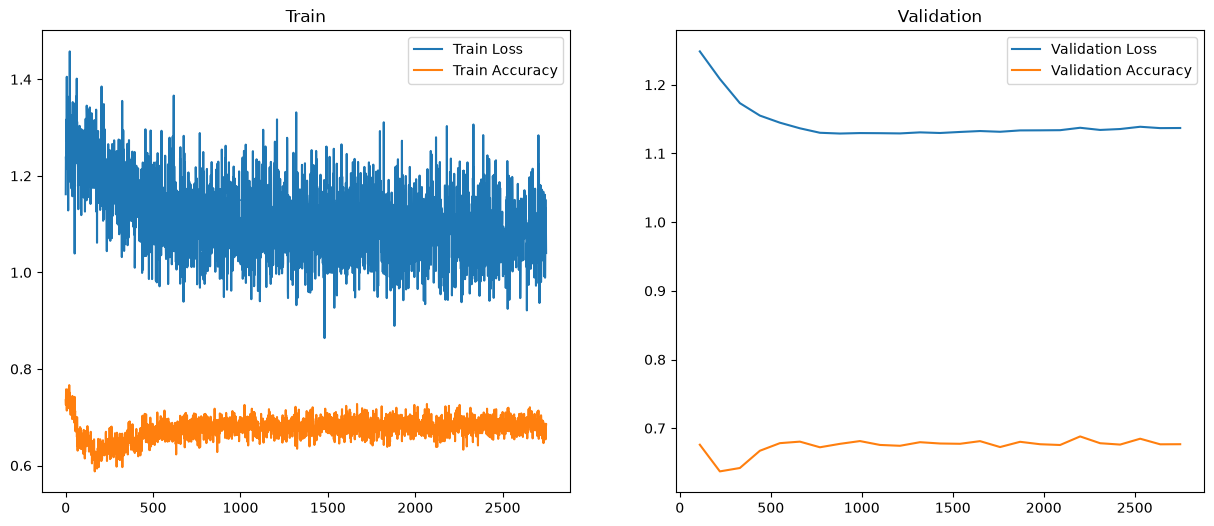

In [29]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.plot(stats["train_step"], stats["train_loss"], label="Train Loss")
ax1.plot(stats["train_step"], stats["train_acc"], label="Train Accuracy")
ax1.set_title("Train")
ax1.legend()

ax2.plot(stats["val_step"], stats["val_loss"], label="Validation Loss")
ax2.plot(stats["val_step"], stats["val_acc"], label="Validation Accuracy")
ax2.set_title("Validation")
ax2.legend()

plt.show()

Saving the model and the used scaler.

In [30]:
scaler_path = os.path.join(models_dir, "scaler.pkl")
with open(scaler_path, "wb") as f:
    pickle.dump(scaler, f)

In [31]:
model_path = os.path.join(models_dir, "fcnn.pt")
torch.save(fcnn.state_dict(), model_path)